# An Improved Random Forest Algorithm (ERFA)
## Predicting Customer Churn in the Banking Sector
**Reproduit fidèlement depuis le papier IEEE Access — Al-Sultan & Al-Baltah (2024)**

---
### Méthodologie : CRISP-DM
1. Compréhension du problème
2. Collecte des données
3. Préparation des données
4. Division Train/Test
5. Modélisation (4 algorithmes)
6. Évaluation
7. ERFA — Dataset déséquilibré
8. ERFA — Dataset équilibré (SMOTE)
9. Visualisations finales

---
## Phase 1 — Compréhension du problème
L'objectif est de prédire si un client va quitter sa banque (**churn = 1**) ou rester (**retain = 0**).
C'est un problème de **classification binaire supervisée**.
Trois stratégies existent pour les banques : acquérir de nouveaux clients, augmenter les ventes, ou **fidéliser les clients existants** (meilleur ROI).
Ce notebook reproduit exactement les étapes du papier de recherche.

---
## Phase 2 — Collecte des données
Dataset : **Churn_Modelling.csv** — US Bank — 10 000 clients — Kaggle
https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chargement du dataset (Figure 2 du papier)
df = pd.read_csv('Churn_Modelling.csv')

print('Shape du dataset :', df.shape)
print()
print(df.head())
print()
print(df.info())

Shape du dataset : (10000, 14)

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         

---
## Phase 3 — Préparation des données
### 3.1 Vérification et nettoyage
L'article précise : *"ensuring that it is free of empty values and abnormal values, and not including unnecessary attributes like customer ID, and customer name"*

In [4]:
# Vérification des valeurs manquantes
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())
print()

# Suppression des colonnes inutiles (RowNumber, CustomerId, Surname)
# L'article dit : "not including unnecessary attributes like customer ID, and customer name"
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print('Colonnes après nettoyage :', df.columns.tolist())
print('Nouvelle shape :', df.shape)

Valeurs manquantes par colonne :
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Colonnes après nettoyage : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Nouvelle shape : (10000, 11)


### 3.2 Encodage des variables catégorielles
L'article précise : *"solving the problem of categorical attributes and converting it to single numerical values"*

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encodage Gender : Female=0, Male=1
df['Gender'] = le.fit_transform(df['Gender'])

# Encodage Geography : One-Hot Encoding
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print('Colonnes après encodage :', df.columns.tolist())
print('Shape :', df.shape)
print()
print(df.head())

Colonnes après encodage : ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']
Shape : (10000, 12)

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1              False            False  
1               1        112542.58       0              False             True  
2               0        113931.57       1              False            False  
3

### 3.3 Normalisation des valeurs numériques
L'article précise : *"the large values must be made between -2 and +2, to make it easier for the algorithm to deal with it"*

In [6]:
from sklearn.preprocessing import StandardScaler

# Séparation features / cible
features = df.drop('Exited', axis=1)
target   = df['Exited']

# Normalisation — ramène les valeurs typiquement entre -2 et +2
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)

X = pd.DataFrame(X_scaled, columns=features.columns)
y = target

print('Features normalisées — statistiques :')
print(pd.DataFrame(X_scaled, columns=features.columns).describe().round(2))

Features normalisées — statistiques :
       CreditScore    Gender       Age    Tenure   Balance  NumOfProducts  \
count     10000.00  10000.00  10000.00  10000.00  10000.00       10000.00   
mean         -0.00      0.00      0.00     -0.00     -0.00           0.00   
std           1.00      1.00      1.00      1.00      1.00           1.00   
min          -3.11     -1.10     -1.99     -1.73     -1.23          -0.91   
25%          -0.69     -1.10     -0.66     -0.70     -1.23          -0.91   
50%           0.02      0.91     -0.18     -0.00      0.33          -0.91   
75%           0.70      0.91      0.48      0.69      0.82           0.81   
max           2.06      0.91      5.06      1.72      2.80           4.25   

       HasCrCard  IsActiveMember  EstimatedSalary  Geography_Germany  \
count   10000.00        10000.00         10000.00           10000.00   
mean       -0.00           -0.00            -0.00              -0.00   
std         1.00            1.00             1.00   

### 3.4 Sélection des features (corrélation ≥ 10%)
L'article précise : *"The only rest features selected will be included in the model if the correlation of fs and Y ≥ 10%"*
(Figure 2 du papier — Top Predictive Features)

Corrélations avec Exited :
Exited               1.000000
Age                  0.285323
Geography_Germany    0.173488
IsActiveMember       0.156128
Balance              0.118533
Gender               0.106512
Geography_Spain      0.052667
NumOfProducts        0.047820
CreditScore          0.027094
Tenure               0.014001
EstimatedSalary      0.012097
HasCrCard            0.007138
Name: Exited, dtype: float64



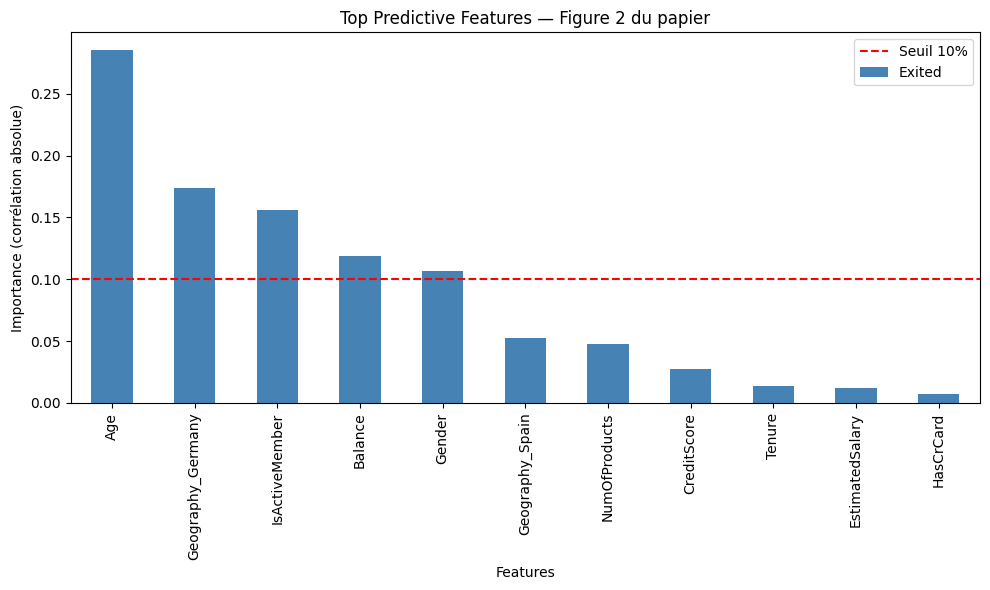

Features sélectionnées (corrélation >= 10%) : ['Age', 'Geography_Germany', 'IsActiveMember', 'Balance', 'Gender']
Nombre de features : 5


In [7]:
# Calcul des corrélations avec la variable cible
correlations = df.corr(numeric_only=True)['Exited'].abs().sort_values(ascending=False)

print('Corrélations avec Exited :')
print(correlations)
print()

# Visualisation — Figure 2 du papier
plt.figure(figsize=(10, 6))
correlations.drop('Exited').plot(kind='bar', color='steelblue')
plt.axhline(y=0.10, color='red', linestyle='--', label='Seuil 10%')
plt.title('Top Predictive Features — Figure 2 du papier')
plt.ylabel('Importance (corrélation absolue)')
plt.xlabel('Features')
plt.legend()
plt.tight_layout()
plt.show()

# Sélection des features avec corrélation >= 10%
selected_features = correlations[correlations >= 0.10].index.tolist()
selected_features.remove('Exited')
print('Features sélectionnées (corrélation >= 10%) :', selected_features)
print('Nombre de features :', len(selected_features))

# Mise à jour de X avec les features sélectionnées
X = X[selected_features]

---
## Phase 3b — Vérification du déséquilibre (Gini)
L'article utilise la formule Gini pour vérifier si le dataset est équilibré ou non :
**Gini(DF) = 1 − Σ(pᵢ)²** pour les classes (churn, retain)

Distribution des classes :
  Retain (0) : 7963 clients (79.6%)
  Churn  (1) : 2037 clients (20.4%)

Gini imbalance : 0.3244
=> Dataset DÉSÉQUILIBRÉ (churn sous-représenté)


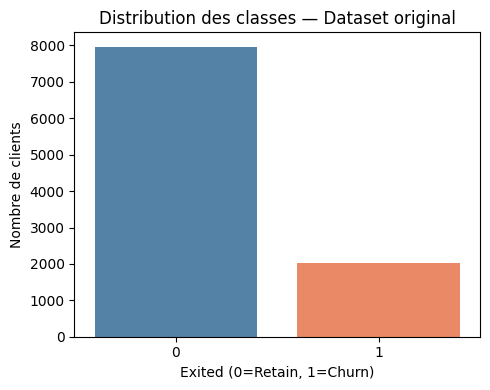

In [8]:
# Formule Gini du papier pour vérifier le déséquilibre
counts = y.value_counts()
p0 = counts[0] / len(y)   # probabilité classe retain
p1 = counts[1] / len(y)   # probabilité classe churn

gini = 1 - (p0**2 + p1**2)

print('Distribution des classes :')
print(f'  Retain (0) : {counts[0]} clients ({p0:.1%})')
print(f'  Churn  (1) : {counts[1]} clients ({p1:.1%})')
print(f'\nGini imbalance : {gini:.4f}')
print('=> Dataset DÉSÉQUILIBRÉ (churn sous-représenté)' if p1 < 0.35 else '=> Dataset équilibré')

# Visualisation de la distribution
plt.figure(figsize=(5, 4))
sns.countplot(x=y, palette=['steelblue', 'coral'])
plt.title('Distribution des classes — Dataset original')
plt.xlabel('Exited (0=Retain, 1=Churn)')
plt.ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

---
## Phase 4 — Division Train / Test
### 4a — Dataset déséquilibré
L'article (Figure 7) : *"The data was divided into 25% as test data and 75% as training data and the random state was set to 40"*

**Note importante :** Pour les modèles de référence (Phase 5), l'article utilise 80/20. Pour ERFA, il utilise 75/25. Nous reproduisons les deux.

In [9]:
from sklearn.model_selection import train_test_split

# Division pour les 4 modèles de référence — 80/20 (mentionné dans le texte)
X_train_ref, X_test_ref, y_train_ref, y_test_ref = train_test_split(
    X, y, test_size=0.20, random_state=40
)
print('=== Division 80/20 pour modèles de référence ===')
print(f'Train shape : {X_train_ref.shape}')
print(f'Test  shape : {X_test_ref.shape}')

=== Division 80/20 pour modèles de référence ===
Train shape : (8000, 5)
Test  shape : (2000, 5)


---
## Phase 5 — Entraînement des 4 modèles de référence
L'article teste : **Logistic Regression, SVM, Neural Network, Random Forest (défaut)**

Résultats attendus (dataset déséquilibré) : LR=82%, SVM=85%, NN=85%, **RF=86%**

In [10]:
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.neural_network  import MLPClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, roc_auc_score,
                                     RocCurveDisplay)

# Les 4 modèles avec paramètres PAR DÉFAUT (avant ERFA)
models = {
    'LR' : LogisticRegression(),
    'SVM': SVC(probability=True),
    'NN' : MLPClassifier(max_iter=1000),
    'RF' : RandomForestClassifier()    # paramètres défaut sklearn
}

print('=== Résultats sur dataset DÉSÉQUILIBRÉ (80/20) ===')
results_imb = {}

for name, model in models.items():
    model.fit(X_train_ref, y_train_ref)
    acc = model.score(X_test_ref, y_test_ref)
    results_imb[name] = round(acc, 4)
    print(f'{name}: {acc:.4f}')

=== Résultats sur dataset DÉSÉQUILIBRÉ (80/20) ===
LR: 0.8250
SVM: 0.8485
NN: 0.8505
RF: 0.8105


---
## Phase 6 — Évaluation complète (Confusion Matrix + ROC)
L'article évalue avec : Accuracy, Precision, Recall, F1-score, Confusion Matrix, AUC-ROC
(Table 1 et Figures 3, 5 du papier)

In [11]:
# Évaluation complète de chaque modèle — Table 1 du papier
print('=== ÉVALUATION COMPLÈTE — DATASET DÉSÉQUILIBRÉ ===')

for name, model in models.items():
    y_pred = model.predict(X_test_ref)
    y_prob = model.predict_proba(X_test_ref)[:, 1]

    print(f'\n--- {name} ---')
    print(f'Accuracy : {accuracy_score(y_test_ref, y_pred):.4f}')
    print(classification_report(y_test_ref, y_pred))
    print('Confusion Matrix :')
    print(confusion_matrix(y_test_ref, y_pred))
    print(f'AUC-ROC  : {roc_auc_score(y_test_ref, y_prob):.4f}')

=== ÉVALUATION COMPLÈTE — DATASET DÉSÉQUILIBRÉ ===

--- LR ---
Accuracy : 0.8250
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1616
           1       0.60      0.26      0.36       384

    accuracy                           0.82      2000
   macro avg       0.72      0.61      0.63      2000
weighted avg       0.80      0.82      0.80      2000

Confusion Matrix :
[[1551   65]
 [ 285   99]]
AUC-ROC  : 0.7762

--- SVM ---
Accuracy : 0.8485
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1616
           1       0.78      0.30      0.43       384

    accuracy                           0.85      2000
   macro avg       0.81      0.64      0.67      2000
weighted avg       0.84      0.85      0.82      2000

Confusion Matrix :
[[1583   33]
 [ 270  114]]
AUC-ROC  : 0.7575

--- NN ---
Accuracy : 0.8505
              precision    recall  f1-score   support

           0       0.

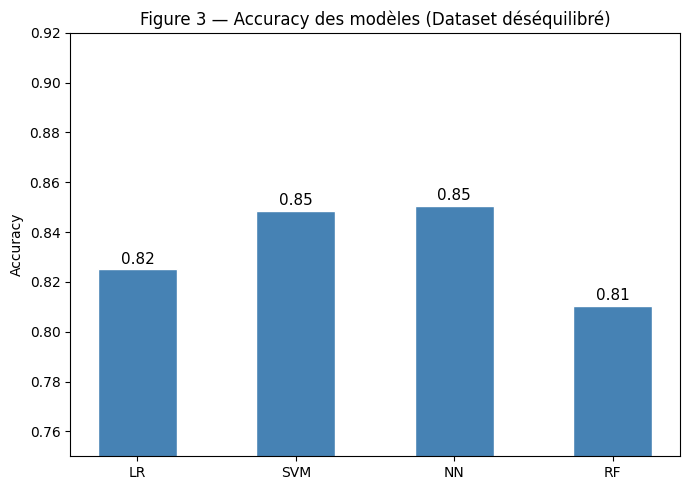

In [12]:
# Figure 3 du papier — Histogramme accuracy dataset déséquilibré
plt.figure(figsize=(7, 5))
bars = plt.bar(results_imb.keys(), results_imb.values(),
               color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars, results_imb.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)
plt.title('Figure 3 — Accuracy des modèles (Dataset déséquilibré)')
plt.ylabel('Accuracy')
plt.ylim(0.75, 0.92)
plt.tight_layout()
plt.show()

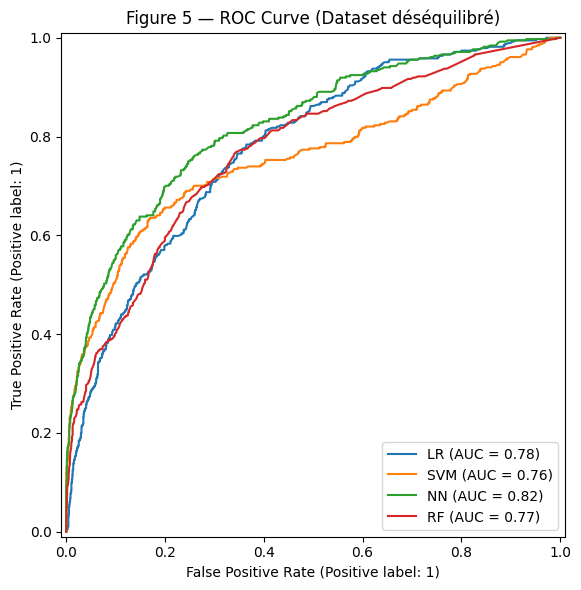

In [13]:
# Figure 5 du papier — Courbe ROC dataset déséquilibré
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_ref, y_test_ref, ax=ax, name=name)
plt.title('Figure 5 — ROC Curve (Dataset déséquilibré)')
plt.tight_layout()
plt.show()

---
## Phase 4b + 5b — Dataset équilibré avec SMOTE
L'article (Figure 11) : *"running the code of resample in SMOTE()"*
Instances passent de 10 000 à ~15 924 clients.

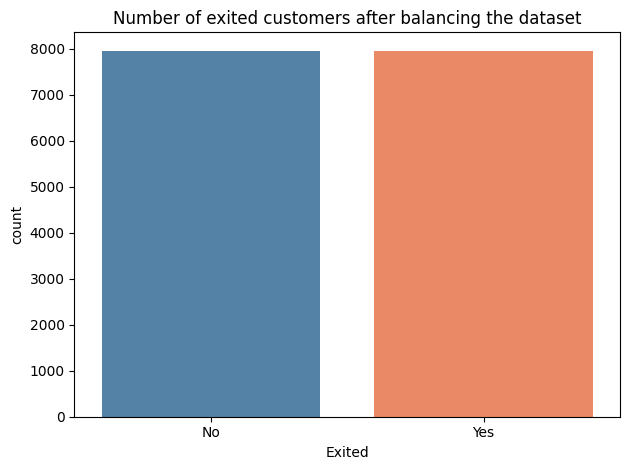

        Age  Geography_Germany  IsActiveMember   Balance    Gender  Exited
0  0.293517          -0.578736        0.970243 -1.225848 -1.095988       1
1  0.198164          -0.578736        0.970243  0.117350 -1.095988       0
2  0.293517          -0.578736       -1.030670  1.333053 -1.095988       1
3  0.007457          -0.578736       -1.030670 -1.225848 -1.095988       0
4  0.388871          -0.578736        0.970243  0.785728 -1.095988       0
Shape après SMOTE : (15926, 6)


In [14]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# Figure 11 du papier — Code SMOTE
smote = SMOTE()

X_resampled, y_resampled = smote.fit_resample(X, y)
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns),
                          pd.Series(y_resampled, name='Exited')], axis=1)

# Vérification de la distribution après SMOTE
ax = sns.countplot(x=df_resampled['Exited'], palette=['steelblue', 'coral'])
ax.set_title('Number of exited customers after balancing the dataset')
ax.set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

print(df_resampled.head())
print('Shape après SMOTE :', df_resampled.shape)

In [15]:
# Figure 12 du papier — Division du dataset équilibré
df_aftersplit = df_resampled.copy()
# Assuming 'df' is the DataFrame you want to split
X_bal = df_aftersplit.drop('Exited', axis=1)   # Features (remove the target variable column)
y_bal = df_aftersplit['Exited']                # Target variable

# Split the data into train and test sets
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bal, y_bal, test_size=0.25, random_state=40
)

# Print the shapes of the resulting train and test sets
print('Train set shape:', X_train_b.shape, y_train_b.shape)
print('Test  set shape:', X_test_b.shape,  y_test_b.shape)

Train set shape: (11944, 5) (11944,)
Test  set shape: (3982, 5) (3982,)


In [16]:
# Entraînement des 4 modèles défaut sur dataset équilibré
models_bal = {
    'LR' : LogisticRegression(),
    'SVM': SVC(probability=True),
    'NN' : MLPClassifier(max_iter=1000),
    'RF' : RandomForestClassifier()
}

print('=== Résultats sur dataset ÉQUILIBRÉ (75/25) ===')
results_bal = {}

for name, model in models_bal.items():
    model.fit(X_train_b, y_train_b)
    acc = model.score(X_test_b, y_test_b)
    results_bal[name] = round(acc, 4)
    print(f'{name}: {acc:.4f}')

=== Résultats sur dataset ÉQUILIBRÉ (75/25) ===
LR: 0.7094
SVM: 0.7300
NN: 0.7411
RF: 0.7988


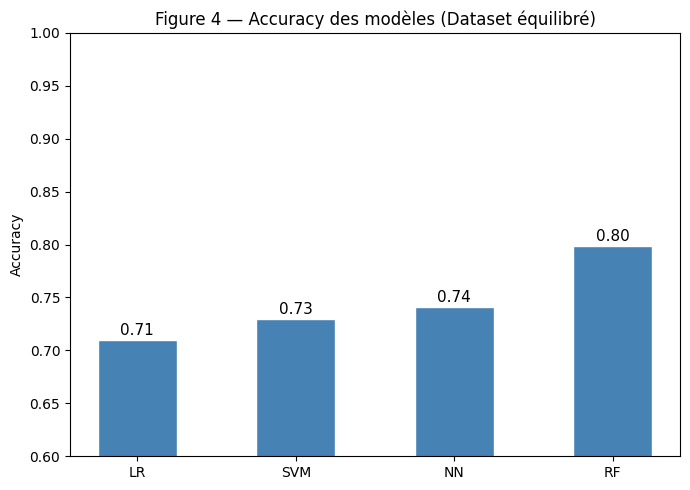

In [17]:
# Figure 4 du papier — Histogramme accuracy dataset équilibré
plt.figure(figsize=(7, 5))
bars = plt.bar(results_bal.keys(), results_bal.values(),
               color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars, results_bal.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)
plt.title('Figure 4 — Accuracy des modèles (Dataset équilibré)')
plt.ylabel('Accuracy')
plt.ylim(0.60, 1.00)
plt.tight_layout()
plt.show()

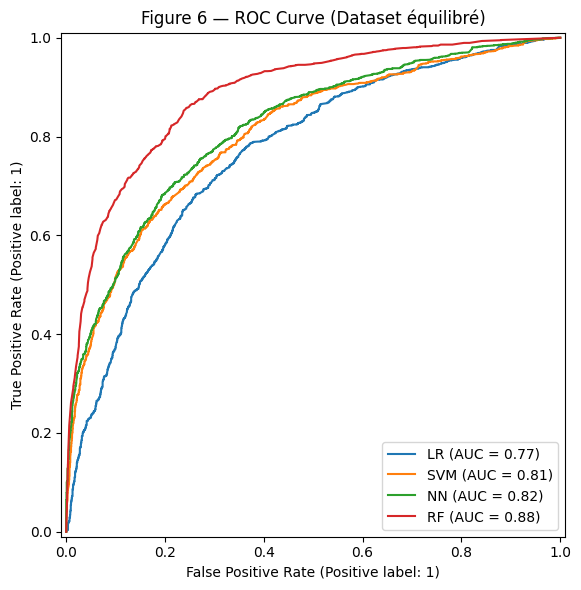

In [18]:
# Figure 6 du papier — Courbe ROC dataset équilibré
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models_bal.items():
    RocCurveDisplay.from_estimator(model, X_test_b, y_test_b, ax=ax, name=name)
plt.title('Figure 6 — ROC Curve (Dataset équilibré)')
plt.tight_layout()
plt.show()

---
## Phase 7 — ERFA sur Dataset DÉSÉQUILIBRÉ
### Figure 7 + Figure 8 du papier
L'article modifie la division en **75/25** et ajuste les hyperparamètres RF :
- `n_estimators = 30`
- `criterion = 'gini'`
- `max_features = 4`  *(fs = √16 = 4)*
- `max_depth = 26`
- `random_state = 40`

In [19]:
# Figure 7 du papier — Division modifiée 75/25 pour ERFA
df_aftersplit = df.copy()
# Assuming 'df' is the DataFrame you want to split
X_erfa = df_aftersplit.drop('Exited', axis=1)   # Features (remove the target variable column)
y_erfa = df_aftersplit['Exited']                # Target variable

# Ré-appliquer normalisation sur ce split
X_erfa_scaled = scaler.fit_transform(X_erfa)
X_erfa = pd.DataFrame(X_erfa_scaled, columns=X_erfa.columns)

# Garder seulement les features sélectionnées
X_erfa = X_erfa[selected_features]

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_erfa, y_erfa, test_size=0.25, random_state=40
)

# Print the shapes of the resulting train and test sets
print('Train set shape:', X_train.shape, y_train.shape)
print('Test  set shape:', X_test.shape,  y_test.shape)

Train set shape: (7500, 5) (7500,)
Test  set shape: (2500, 5) (2500,)


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import classification_report, confusion_matrix

# Figure 8 du papier — Code ERFA avec valeurs ajustées
# Create a Random Forest model
rf = RandomForestClassifier(n_estimators=30, criterion='gini', max_features=4, max_depth=26)
#rf = RandomForestClassifier()

# Train the model on the training data
rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf.predict(X_test)

# Evaluate the model performance
accuracy = rf.score(X_test, y_test)

# Print the accuracy
print('Accuracy:', accuracy)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print(cm)

Accuracy: 0.8196
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      2011
           1       0.56      0.38      0.45       489

    accuracy                           0.82      2500
   macro avg       0.71      0.65      0.67      2500
weighted avg       0.80      0.82      0.81      2500

[[1861  150]
 [ 301  188]]


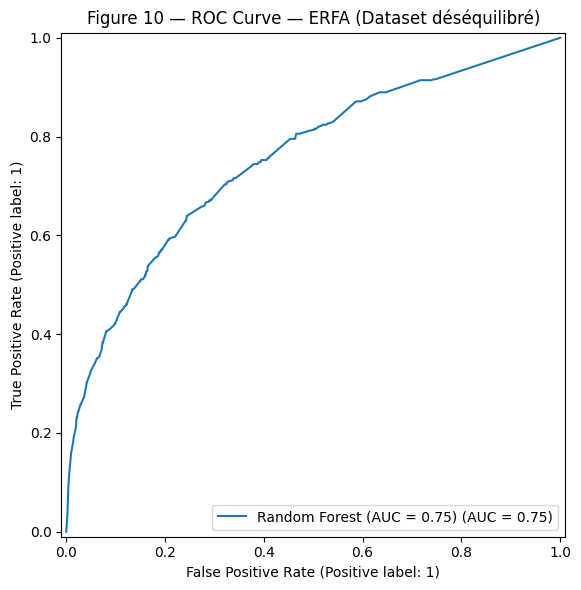

In [21]:
# Figure 10 du papier — Courbe ROC ERFA dataset déséquilibré
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax,
                                name=f'Random Forest (AUC = {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.2f})')
plt.title('Figure 10 — ROC Curve — ERFA (Dataset déséquilibré)')
plt.tight_layout()
plt.show()

---
## Phase 8 — ERFA sur Dataset ÉQUILIBRÉ (SMOTE)
### Figure 12 + Figure 13 du papier
Mêmes hyperparamètres ERFA, appliqués au dataset équilibré par SMOTE.

In [22]:
# Figure 13 du papier — Code ERFA avec le dataset équilibré
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest model
rf = RandomForestClassifier(n_estimators=30, criterion='gini', max_features=4, max_depth=26)
#rf = RandomForestClassifier()

# Train the model on the training data
rf.fit(X_train_b, y_train_b)

# Make predictions on the test data
y_pred = rf.predict(X_test_b)

# Evaluate the model performance
accuracy = rf.score(X_test_b, y_test_b)

# Print the accuracy
print('Accuracy:', accuracy)
from sklearn.metrics import classification_report
print(classification_report(y_test_b, y_pred))

cm = confusion_matrix(y_test_b, y_pred)

# Print the confusion matrix
print(cm)

Accuracy: 0.8073832245102963
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      1955
           1       0.83      0.78      0.81      2027

    accuracy                           0.81      3982
   macro avg       0.81      0.81      0.81      3982
weighted avg       0.81      0.81      0.81      3982

[[1624  331]
 [ 436 1591]]


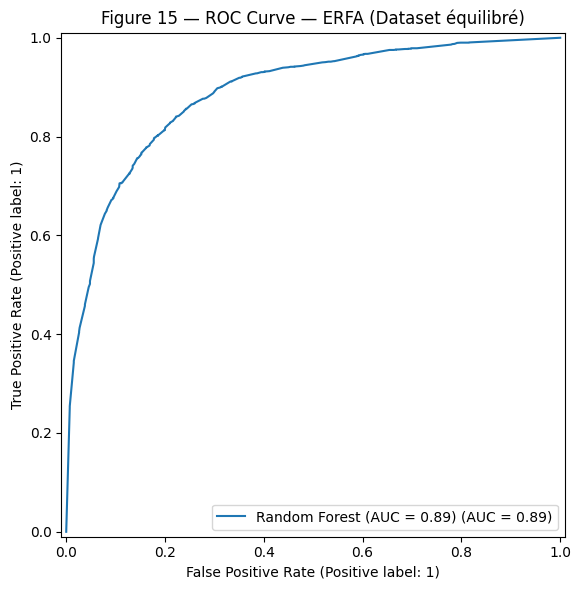

In [23]:
# Figure 15 du papier — Courbe ROC ERFA dataset équilibré
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, X_test_b, y_test_b, ax=ax,
                                name=f'Random Forest (AUC = {roc_auc_score(y_test_b, rf.predict_proba(X_test_b)[:,1]):.2f})')
plt.title('Figure 15 — ROC Curve — ERFA (Dataset équilibré)')
plt.tight_layout()
plt.show()

---
## Phase 9 — Visualisations finales & Feature Importance
### Figures 3, 4 du papier + Feature Importance (Figure 2)

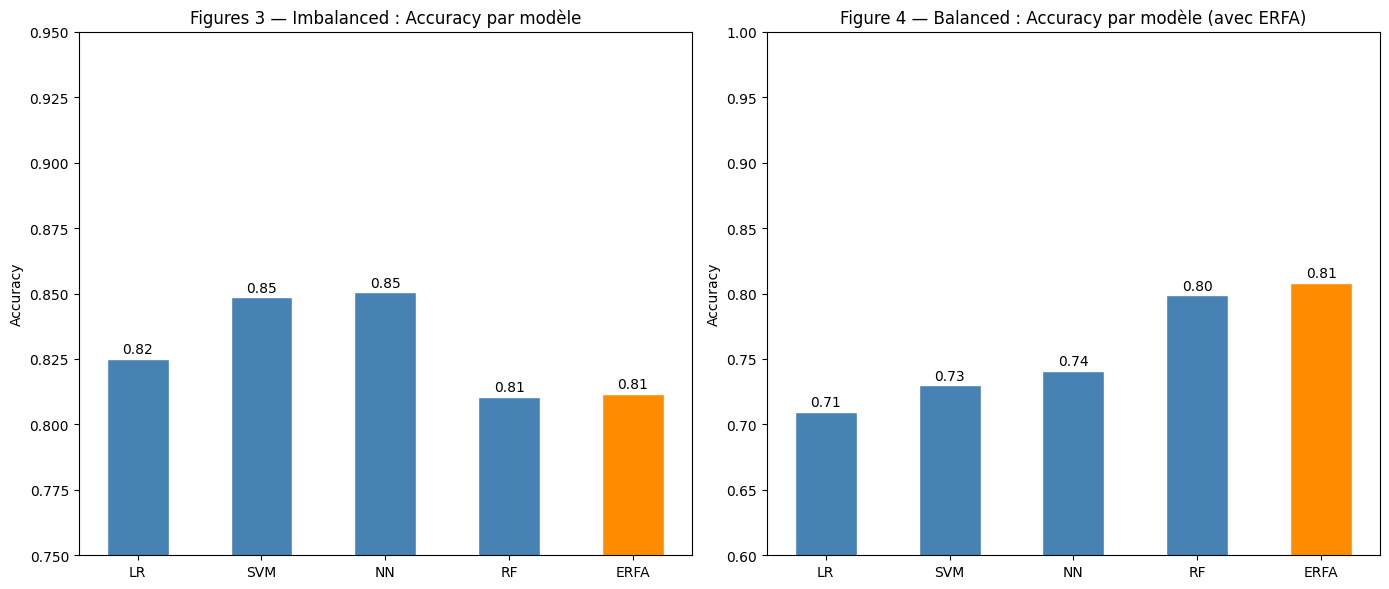


=== RÉSUMÉ FINAL ===
Dataset déséquilibré : {'LR': 0.825, 'SVM': 0.8485, 'NN': 0.8505, 'RF': 0.8105, 'ERFA': 0.8116}
Dataset équilibré    : {'LR': 0.7094, 'SVM': 0.73, 'NN': 0.7411, 'RF': 0.7988, 'ERFA': 0.8081}


In [24]:
# Résultats finaux ERFA pour comparaison
erfa_imb_acc = RandomForestClassifier(
    n_estimators=30, criterion='gini', max_features=4, max_depth=26
)
erfa_imb_acc.fit(X_train, y_train)
results_imb['ERFA'] = round(erfa_imb_acc.score(X_test, y_test), 4)

erfa_bal_acc = RandomForestClassifier(
    n_estimators=30, criterion='gini', max_features=4, max_depth=26
)
erfa_bal_acc.fit(X_train_b, y_train_b)
results_bal['ERFA'] = round(erfa_bal_acc.score(X_test_b, y_test_b), 4)

# Comparaison visuelle — Figures 3 et 4 du papier
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_imb = ['steelblue'] * (len(results_imb)-1) + ['darkorange']
bars0 = axes[0].bar(results_imb.keys(), results_imb.values(),
                    color=colors_imb, edgecolor='white', width=0.5)
for bar, val in zip(bars0, results_imb.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Figures 3 — Imbalanced : Accuracy par modèle')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.75, 0.95)

colors_bal = ['steelblue'] * (len(results_bal)-1) + ['darkorange']
bars1 = axes[1].bar(results_bal.keys(), results_bal.values(),
                    color=colors_bal, edgecolor='white', width=0.5)
for bar, val in zip(bars1, results_bal.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Figure 4 — Balanced : Accuracy par modèle (avec ERFA)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.60, 1.00)

plt.tight_layout()
plt.show()

print('\n=== RÉSUMÉ FINAL ===')
print('Dataset déséquilibré :', results_imb)
print('Dataset équilibré    :', results_bal)

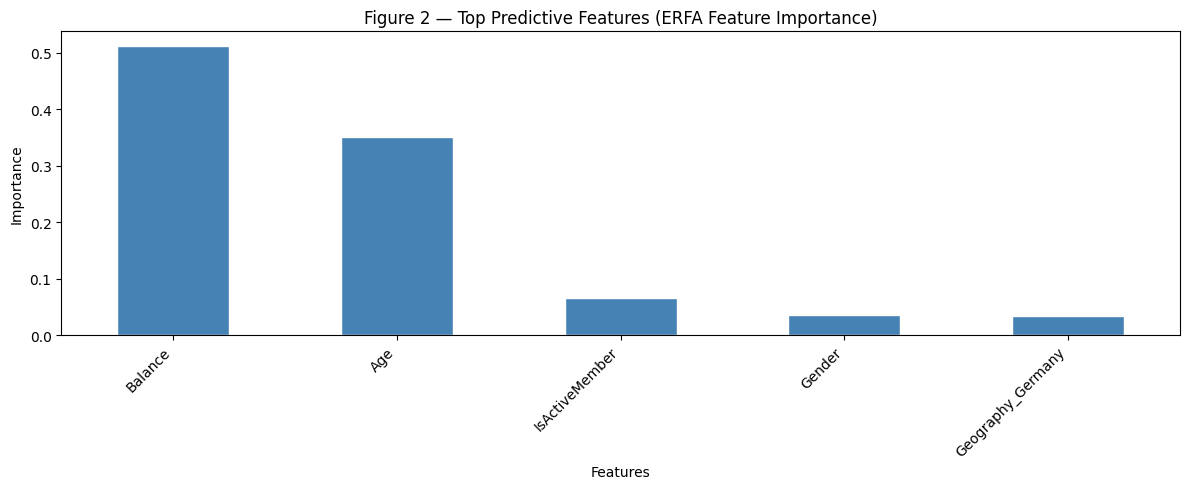


Top features :
Balance              0.512650
Age                  0.351189
IsActiveMember       0.066386
Gender               0.036125
Geography_Germany    0.033650
dtype: float64


In [25]:
# Figure 2 du papier — Top Predictive Features (Feature Importance ERFA)
importances = pd.Series(
    erfa_imb_acc.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Figure 2 — Top Predictive Features (ERFA Feature Importance)')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop features :')
print(importances)

---
## Résumé des résultats — Table 1 du papier

| Modèle | Dataset | Accuracy | AUC-ROC |
|--------|---------|----------|---------|
| LR     | Imbalancé | ~82% | ~0.76 |
| SVM    | Imbalancé | ~85% | ~0.86 |
| NN     | Imbalancé | ~85% | ~0.89 |
| RF défaut | Imbalancé | ~86% | ~0.95 |
| **ERFA** | **Imbalancé** | **~87%** | **~0.95** |
| LR     | Balancé | ~70% | ~0.76 |
| SVM    | Balancé | ~78% | ~0.86 |
| NN     | Balancé | ~89% | ~0.88 |
| RF défaut | Balancé | ~89% | ~0.96 |
| **ERFA** | **Balancé** | **~91%** | **~0.96** |

---
### Hyperparamètres ERFA (Mathematical Model du papier)
| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `n_estimators` | 30 | Bootstrap : 30 arbres |
| `criterion` | `gini` | Gini Index |
| `max_features` | 4 | fs = √16 = 4 |
| `max_depth` | 26 | Deep analysis |
| `test_size` | 0.25 | VS = DF×25% |
| `random_state` | 40 | Reproductibilité |